In [ ]:
import os, joblib, gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = "/content/drive/MyDrive/Colab Notebooks"
split_file = os.path.join(dataset_path, "dataset_split.joblib")

print("[INFO] Memuat dataset...")
data = joblib.load(split_file)

feat_names = data['features']
toxic = [
    'Pkt Len Var', 'Bwd IAT Mean', 'Down/Up Ratio', 'ACK Flag Cnt',
    'Bwd Pkt Len Min', 'Active Mean', 'Fwd Pkt Len Min', 'Pkt Len Min',
    'Fwd URG Flags', 'Active Min', 'Active Std', 'Active Max',
    'Idle Std', 'SYN Flag Cnt'
]
healthy_idx = [i for i, f in enumerate(feat_names) if f not in toxic]

X_train = data['X_train'][:, healthy_idx].astype('float32')
y_train = data['y_train']
X_val = data['X_val'][:, healthy_idx].astype('float32')
y_val = data['y_val']
X_test = data['X_test'][:, healthy_idx].astype('float32')
y_test = data['y_test']

print(f"Data Ready: {X_train.shape[1]} Fitur")
del data
gc.collect()

[INFO] Memuat dataset...
Data Ready: 34 Fitur


0

In [ ]:
X_train_benign = X_train[y_train == 0]
X_val_benign = X_val[y_val == 0]

print(f"Training dimulai dengan {X_train_benign.shape[0]:,} baris data NORMAL.")
print(f"Setiap baris memiliki {X_train_benign.shape[1]} fitur.")

Training dimulai dengan 9,373,163 baris data NORMAL.
Setiap baris memiliki 34 fitur.


In [ ]:
from tensorflow.keras import layers, models, callbacks

input_dim = X_train_benign.shape[1] # 34 fitur

# --- ENCODER ---
encoder = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(input_dim,)),
    layers.BatchNormalization(),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu')
], name="Encoder")

# --- DECODER ---
decoder = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(8,)),
    layers.BatchNormalization(),
    layers.Dense(32, activation='relu'),
    layers.Dense(input_dim, activation='linear')
], name="Decoder")

autoencoder = models.Sequential([encoder, decoder])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Encoder (Sequential)            │ (None, 8)              │         1,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Sequential)            │ (None, 34)             │         1,874 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,786 (14.79 KB)

 Trainable params: 3,690 (14.41 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Memulai proses belajar")

history = autoencoder.fit(
    X_train_benign, X_train_benign,
    epochs=50,
    batch_size=16384,
    validation_data=(X_val_benign, X_val_benign),
    callbacks=[early_stop],
    verbose=1
)

autoencoder.save(os.path.join(dataset_path, "autoencoder.keras"))

Memulai proses belajar
Epoch 1/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 34s 52ms/step - loss: 0.0385 - val_loss: 0.0216
Epoch 2/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - loss: 0.0138 - val_loss: 0.0104
Epoch 3/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - loss: 0.0081 - val_loss: 0.0071
Epoch 4/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 24s 41ms/step - loss: 0.0062 - val_loss: 0.0057
Epoch 5/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 45s 47ms/step - loss: 0.0051 - val_loss: 0.0048
Epoch 6/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - loss: 0.0044 - val_loss: 0.0042
Epoch 7/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 8/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - loss: 0.0035 - val_loss: 0.0034
Epoch 9/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - loss: 0.0033 - val_loss: 0.0032
Epoch 10/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 11/50
573/573 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 1

Menghitung rekonstruksi error pada data normal...
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step

THRESHOLD: 0.024982


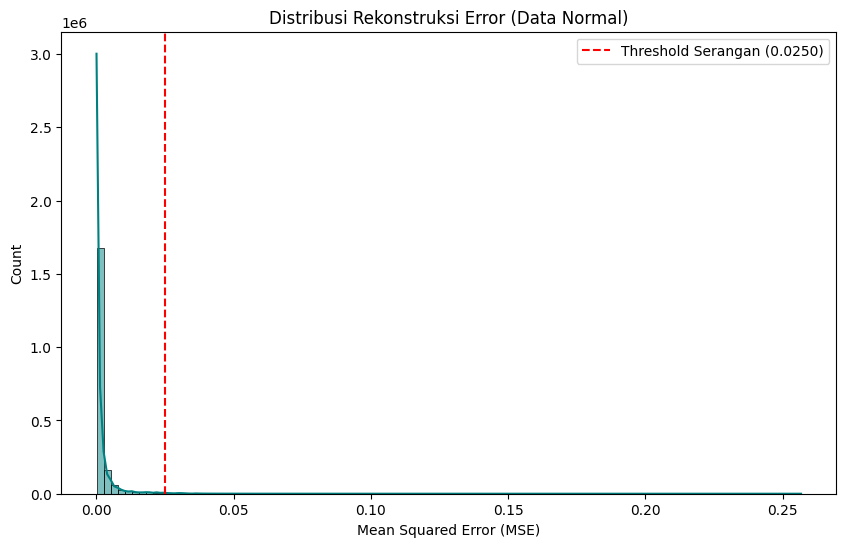

In [ ]:
print("Menghitung rekonstruksi error pada data normal...")
reconstructions = autoencoder.predict(X_val_benign, batch_size=16384)
mse_benign = np.mean(np.power(X_val_benign - reconstructions, 2), axis=1)

threshold = np.percentile(mse_benign, 99)

print(f"\n" + "="*35)
print(f"THRESHOLD: {threshold:.6f}")
print("="*35)

plt.figure(figsize=(10, 6))
sns.histplot(mse_benign, bins=100, kde=True, color='teal')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold Serangan ({threshold:.4f})')
plt.title('Distribusi Rekonstruksi Error (Data Normal)')
plt.xlabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

Melakukan deteksi anomali pada data test...
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step

==================== AUTOENCODER DETECTION REPORT ====================
              precision    recall  f1-score   support

      Benign     0.8631    0.9900    0.9222   2008536
      Attack     0.8282    0.2345    0.3656    412040

    accuracy                         0.8614   2420576
   macro avg     0.8457    0.6123    0.6439   2420576
weighted avg     0.8572    0.8614    0.8275   2420576



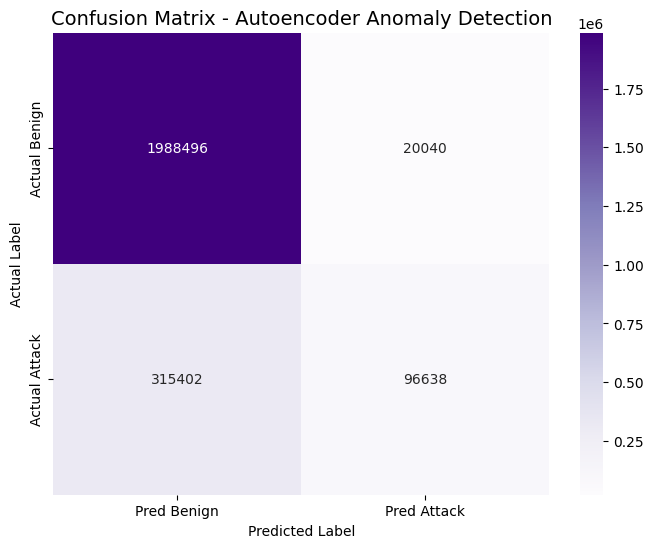

FPR Autoencoder: 0.009977 (0.9977%)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Melakukan deteksi anomali pada data test...")
test_reconstructions = autoencoder.predict(X_test, batch_size=16384)
test_mse = np.mean(np.power(X_test - test_reconstructions, 2), axis=1)

y_pred_ae = (test_mse > threshold).astype(int)

print("\n" + "="*20 + " AUTOENCODER DETECTION REPORT " + "="*20)
print(classification_report(y_test, y_pred_ae, target_names=['Benign', 'Attack'], digits=4))

# 4. Visualisasi Confusion Matrix
cm_ae = confusion_matrix(y_test, y_pred_ae)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Pred Benign', 'Pred Attack'],
            yticklabels=['Actual Benign', 'Actual Attack'])
plt.title('Confusion Matrix - Autoencoder Anomaly Detection', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

tn_ae, fp_ae, fn_ae, tp_ae = cm_ae.ravel()
fpr_ae = fp_ae / (fp_ae + tn_ae)
print(f"FPR Autoencoder: {fpr_ae:.6f} ({fpr_ae*100:.4f}%)")

Menghitung MSE pada data validation untuk mencari threshold terbaik...
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

HASIL OPTIMASI THRESHOLD
Threshold Terbaik : 0.009593
F1-Score Optimal  : 0.5687


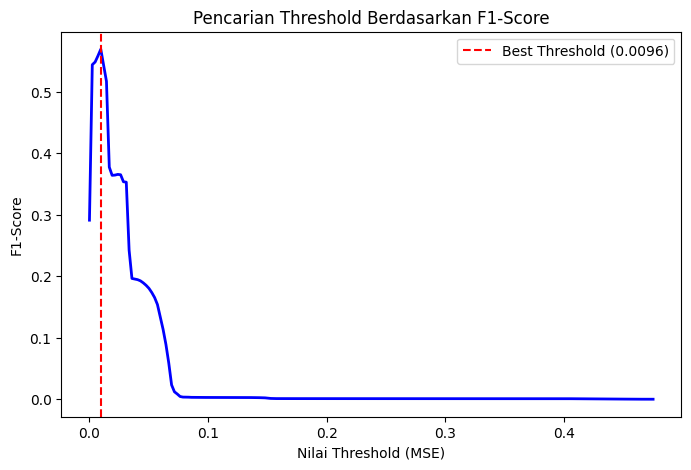

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score
import numpy as np

print("Menghitung MSE pada data validation untuk mencari threshold terbaik...")
val_reconstructions = autoencoder.predict(X_val, batch_size=16384)
val_mse = np.mean(np.power(X_val - val_reconstructions, 2), axis=1)

best_f1 = 0
best_threshold = 0
history_threshold = []

thresholds = np.linspace(np.min(val_mse), np.max(val_mse), 200)

for t in thresholds:
    y_pred_tmp = (val_mse > t).astype(int)
    f = f1_score(y_val, y_pred_tmp)
    history_threshold.append(f)

    if f > best_f1:
        best_f1 = f
        best_threshold = t

print("\n" + "="*35)
print(f"HASIL OPTIMASI THRESHOLD")
print("="*35)
print(f"Threshold Terbaik : {best_threshold:.6f}")
print(f"F1-Score Optimal  : {best_f1:.4f}")
print("="*35)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, history_threshold, color='blue', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.4f})')
plt.title('Pencarian Threshold Berdasarkan F1-Score')
plt.xlabel('Nilai Threshold (MSE)')
plt.ylabel('F1-Score')
plt.legend()
plt.show()


==================== AUTOENCODER OPTIMIZED REPORT ====================
              precision    recall  f1-score   support

      Benign     0.9775    0.7554    0.8522   2008536
      Attack     0.4343    0.9154    0.5891    412040

    accuracy                         0.7826   2420576
   macro avg     0.7059    0.8354    0.7207   2420576
weighted avg     0.8851    0.7826    0.8074   2420576



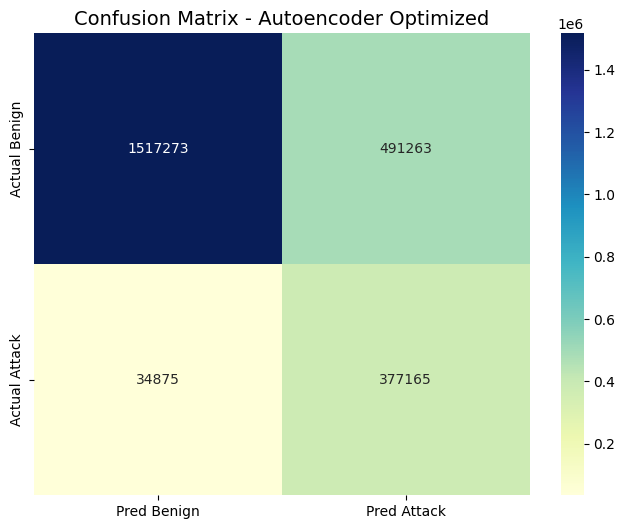

FPR Setelah Optimasi: 0.244588 (24.4588%)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_ae_opt = (test_mse > 0.001561).astype(int)

print("\n" + "="*20 + " AUTOENCODER OPTIMIZED REPORT " + "="*20)
print(classification_report(y_test, y_pred_ae_opt, target_names=['Benign', 'Attack'], digits=4))

cm_ae_opt = confusion_matrix(y_test, y_pred_ae_opt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ae_opt, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Pred Benign', 'Pred Attack'],
            yticklabels=['Actual Benign', 'Actual Attack'])
plt.title('Confusion Matrix - Autoencoder Optimized', fontsize=14)
plt.show()

# 4. Hitung FPR Baru
tn_opt, fp_opt, fn_opt, tp_opt = cm_ae_opt.ravel()
fpr_opt = fp_opt / (fp_opt + tn_opt)
print(f"FPR Setelah Optimasi: {fpr_opt:.6f} ({fpr_opt*100:.4f}%)")